In [71]:
using VeryDiff, LinearAlgebra, Plots

# Out of Bounds

step, |error|,  |level|,  tol_diff, ref_diff
1     0.366117  0.258883  0.016612  10.000000
2     0.312500  0.312500  0.000000  0.000000
Tolerance of 1.0e-10 reached (2.579925170969555e-17)!
step, |error|,  |level|,  tol_diff, ref_diff
1     0.127749  0.111645  0.002495  10.000000
2     0.240230  0.116198  0.019215  1.039509
3     0.172867  0.168537  0.000671  0.145527
4     0.169054  0.169051  0.000000  0.004644
5     0.169052  0.169052  0.000000  0.000004
Tolerance of 1.0e-10 reached (4.12009749928553e-13)!
step, |error|,  |level|,  tol_diff, ref_diff
1     0.227273  0.000000  0.035209  10.000000
2     0.116268  0.018759  0.015106  0.647660
3     0.079458  0.067996  0.001776  0.203811
4     0.069694  0.069566  0.000020  0.024928
5     0.069613  0.069613  0.000000  0.000178
6     0.069613  0.069613  0.000000  0.000000
Tolerance of 1.0e-10 reached (1.055619382455043e-15)!


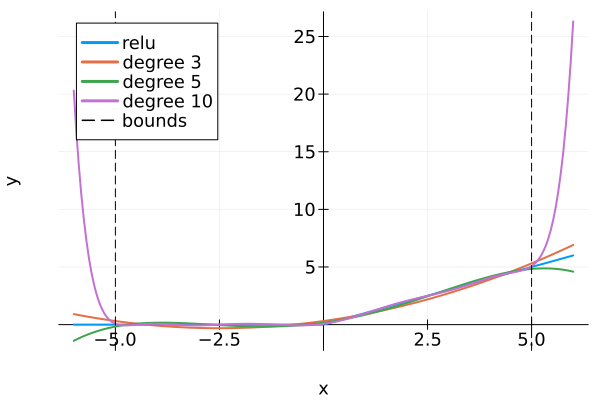

In [2]:
## Show that polynomial approximation outside of approximation domain explodes to ±∞
f = x -> max(0, x)
l = -5.
u = 5.

fontsize = 12

cs3, ϵ3 = VeryDiff.approx_relu_poly(l, u, 3, verbosity=1)
cs5, ϵ5 = VeryDiff.approx_relu_poly(l, u, 5, verbosity=1)
cs10, ϵ10 = VeryDiff.approx_relu_poly(l, u, 10, verbosity=1)

fc3 = VeryDiff.make_eval_chebyshev(cs3, l, u)
fc5 = VeryDiff.make_eval_chebyshev(cs5, l, u)
fc10 = VeryDiff.make_eval_chebyshev(cs10, l, u)

xs = range(l-1, u+1, 200)
plot(xs, f.(xs), label="relu", framestyle=:origin, xlabel="x", ylabel="y", legendfontsize=fontsize, 
     xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, linewidth=2)
plot!(xs, fc3.(xs), label="degree 3", linewidth=2)
plot!(xs, fc5.(xs), label="degree 5", linewidth=2)
plot!(xs, fc10.(xs), label="degree 10", linewidth=2)
vline!([l, u], label="bounds", color=:black, linestyle=:dash)

In [55]:
savefig("relu_poly_approx_out_of_bounds.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/relu_poly_approx_out_of_bounds.pdf"

# Numerical Error with Monomial Basis

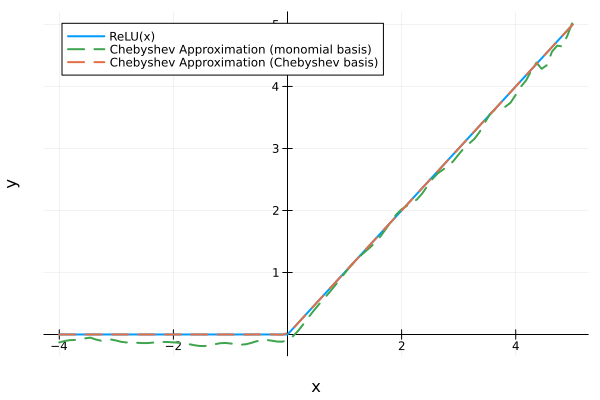

In [112]:
f = x -> max(0, x)

l = -4.
u = 5.
degree = 100
kind = 2

xs = range(l,  u, 100)

cs_monomial = VeryDiff.chebyshev_approximation(f, l, u, degree, kind=2)
f_monomial = VeryDiff.make_eval_poly(cs_monomial)

cs_cheby = VeryDiff.chebyshev_coefficients(f, l, u, degree, kind=2)
f_cheby = x -> VeryDiff.clenshaw_chebyshev(cs_cheby, x, l, u)

p = plot(xs, f.(xs), label="ReLU(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=2)
plot!((xs, f_monomial.(xs)), label="Chebyshev Approximation (monomial basis)", linestyle=:dash, linewidth=2, color=3)
plot!((xs, f_cheby.(xs)), label="Chebyshev Approximation (Chebyshev basis)", linestyle=:dash, linewidth=2, color=2)

In [21]:
savefig(p, "monomial_vs_chebyshev_numerical.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/monomial_vs_chebyshev_numerical.pdf"

For presentation

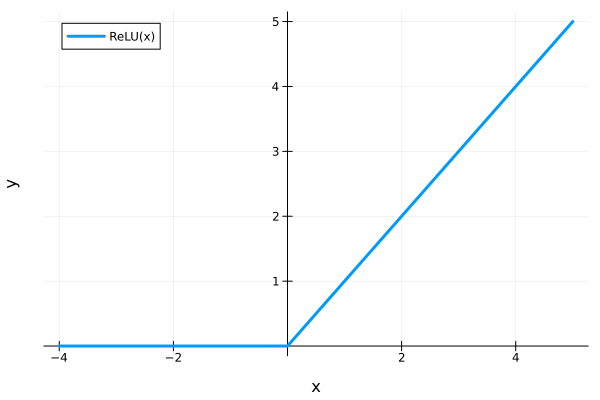

In [119]:
f = x -> max(0, x)

l = -4.
u = 5.
degree = 100
kind = 2

xs = range(l,  u, 100)

cs_monomial = VeryDiff.chebyshev_approximation(f, l, u, degree, kind=2)
f_monomial = VeryDiff.make_eval_poly(cs_monomial)

cs_cheby = VeryDiff.chebyshev_coefficients(f, l, u, degree, kind=2)
f_cheby = x -> VeryDiff.clenshaw_chebyshev(cs_cheby, x, l, u)

p = plot(xs, f.(xs), label="ReLU(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=3)
#plot!((xs, f_monomial.(xs)), label="Chebyshev Approximation (monomial basis)", linestyle=:dash, linewidth=2, color=3)
#plot!((xs, f_cheby.(xs)), label="Chebyshev Approximation (Chebyshev basis)", linestyle=:dash, linewidth=2, color=2)

In [120]:
savefig(p, "presentation/numerical/01_relu.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/numerical/01_relu.pdf"

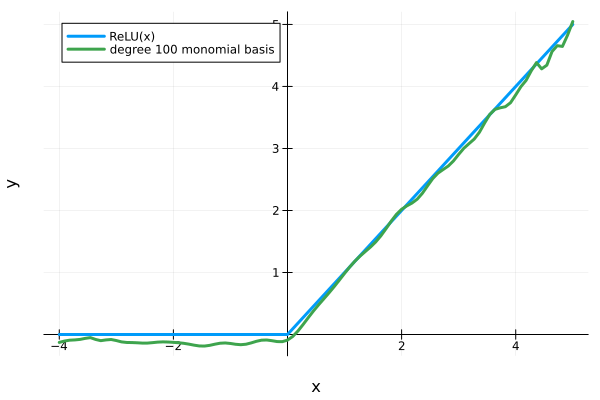

In [122]:
f = x -> max(0, x)

l = -4.
u = 5.
degree = 100
kind = 2

xs = range(l,  u, 100)

cs_monomial = VeryDiff.chebyshev_approximation(f, l, u, degree, kind=2)
f_monomial = VeryDiff.make_eval_poly(cs_monomial)

cs_cheby = VeryDiff.chebyshev_coefficients(f, l, u, degree, kind=2)
f_cheby = x -> VeryDiff.clenshaw_chebyshev(cs_cheby, x, l, u)

p = plot(xs, f.(xs), label="ReLU(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=3)
plot!((xs, f_monomial.(xs)), label="degree 100 monomial basis", linewidth=3, color=3)
#plot!((xs, f_cheby.(xs)), label="Chebyshev Approximation (Chebyshev basis)", linestyle=:dash, linewidth=2, color=2)

In [123]:
savefig(p, "presentation/numerical/02_monomial.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/numerical/02_monomial.pdf"

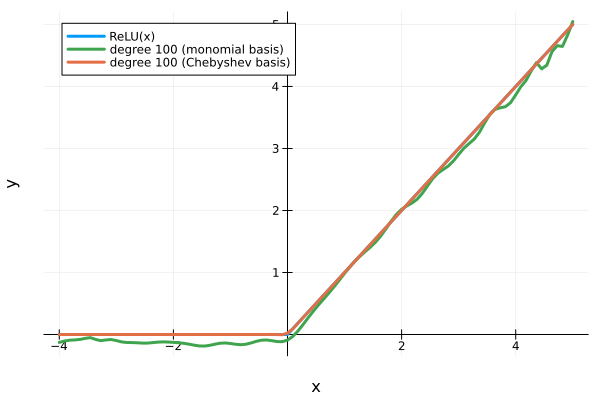

In [124]:
f = x -> max(0, x)

l = -4.
u = 5.
degree = 100
kind = 2

xs = range(l,  u, 100)

cs_monomial = VeryDiff.chebyshev_approximation(f, l, u, degree, kind=2)
f_monomial = VeryDiff.make_eval_poly(cs_monomial)

cs_cheby = VeryDiff.chebyshev_coefficients(f, l, u, degree, kind=2)
f_cheby = x -> VeryDiff.clenshaw_chebyshev(cs_cheby, x, l, u)

p = plot(xs, f.(xs), label="ReLU(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=3)
plot!((xs, f_monomial.(xs)), label="degree 100 (monomial basis)", linewidth=3, color=3)
plot!((xs, f_cheby.(xs)), label="degree 100 (Chebyshev basis)", linewidth=3, color=2)

In [125]:
savefig(p, "presentation/numerical/03_chebyshev.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/numerical/03_chebyshev.pdf"

# Incomparable Zonotope Relaxations

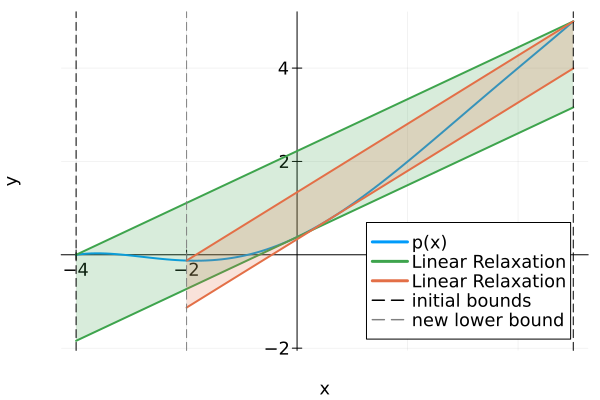

In [41]:
f = x -> max(0, x)

l = -4.
u = 5.
degree = 5
kind = 2

fontsize = 12

xs = range(l, u, 100)
xs2 = range(l+2, u, 100)

cs_all = VeryDiff.chebyshev_coefficients(f, l, u, degree, kind=2)
f_all = x -> VeryDiff.clenshaw_chebyshev(cs_all, x, l, u)

a, b, ϵ = VeryDiff.get_linear_relaxation_cheby(reshape(cs_all, 1, :), [l], [u], [l], [u])

a2, b2, ϵ2 = VeryDiff.get_linear_relaxation_cheby(reshape(cs_all, 1, :), [l], [u], [l+2], [u])


p = plot(xs, f_all.(xs), label="p(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=2, xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, 
legendfontsize=fontsize)
plot!(xs, a[1] * xs .+ b[1] .- ϵ[1], fillrange=a[1] * xs .+ b[1] .+ ϵ[1], label=false, color=3, alpha=0.2)
plot!(xs, a[1] * xs .+ b[1] .- ϵ[1], label="Linear Relaxation", linewidth=2, color=3)
plot!(xs, a[1] * xs .+ b[1] .+ ϵ[1], label=false, linewidth=2, color=3)
plot!(xs2, a2[1] * xs2 .+ b2[1] .- ϵ2[1], fillrange=a2[1] * xs2 .+ b2[1] .+ ϵ2[1], label=false, color=2, alpha=0.2)
plot!(xs2, a2[1] * xs2 .+ b2[1] .- ϵ2[1], label="Linear Relaxation", linewidth=2, color=2)
plot!(xs2, a2[1] * xs2 .+ b2[1] .+ ϵ2[1], label=false, linewidth=2, color=2)

vline!([l, u], label="initial bounds", linestyle=:dash, color=:black)
vline!([l+2], label="new lower bound", linestyle=:dash, color=:gray)

In [42]:
savefig(p, "incomparable_relaxations.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/incomparable_relaxations.pdf"

# Quick Chec for Number of Remez Iterations

In [57]:
f = x -> max(0, x)
l = -5.
u = 5.

cs3, ϵ3 = VeryDiff.approx_relu_poly(l, u, 10, verbosity=1)
cs5, ϵ5 = VeryDiff.approx_relu_poly(l, u, 50, verbosity=1)
cs10, ϵ10 = VeryDiff.approx_relu_poly(l, u, 200, verbosity=1)

step, |error|,  |level|,  tol_diff, ref_diff
1     0.227273  0.000000  0.035209  10.000000
2     0.116268  0.018759  0.015106  0.647660
3     0.079458  0.067996  0.001776  0.203811
4     0.069694  0.069566  0.000020  0.024928
5     0.069613  0.069613  0.000000  0.000178
6     0.069613  0.069613  0.000000  0.000000
Tolerance of 1.0e-10 reached (1.055619382455043e-15)!
step, |error|,  |level|,  tol_diff, ref_diff
1     0.049020  0.000000  0.007594  10.000000
2     0.026230  0.000692  0.003956  0.169545
3     0.022016  0.012800  0.001428  0.093884
4     0.014292  0.013870  0.000065  0.021702
5     0.014006  0.014005  0.000000  0.001001
6     0.014005  0.014005  0.000000  0.000002
Tolerance of 1.0e-10 reached (3.9450818254998826e-13)!
step, |error|,  |level|,  tol_diff, ref_diff
1     0.012438  0.000000  0.001927  10.000000
2     0.006709  0.000036  0.001034  0.123878
3     0.007034  0.002977  0.000629  0.028680
4     0.003683  0.003413  0.000042  0.008651
5     0.003503  0.003502  0.00000

([1.5915457399538693, 2.4999999999984537, 1.0610403363238248, -1.5477517943500442e-12, -0.2122139745227672, -1.548013984793012e-12, 0.09095306775253835, -1.5479942718291118e-12, -0.05053276790741453, -1.5482465678430534e-12  …  -1.546303115933234e-12, -0.00010098184500886853, -1.5473985287561831e-12, 9.946904806994975e-5, -1.5498131857721864e-12, -9.801996084562127e-5, -1.54937487752832e-12, 9.663287631702533e-5, -1.5571348897791549e-12, -0.0035500411071995846], 0.003502064086649881)

# Polynomial Approximation for Presentation

In [2]:
## Show that polynomial approximation outside of approximation domain explodes to ±∞
f = x -> max(0, x)
l = -5.
u = 5.

fontsize = 12

println("----- Chebyshev approximation (1 iteration) -----")
cs1, ϵ1 = VeryDiff.approx_relu_poly(l, u, 3, verbosity=3, max_iter=1)
println()
println("----- Best polynomial approximation -----")
cs, ϵ = VeryDiff.approx_relu_poly(l, u, 3, verbosity=3, max_iter=100)

----- Chebyshev approximation (1 iteration) -----
step, |error|,  |level|,  tol_diff, ref_diff
1     0.366117  0.258883  0.016612  10.000000
	p = [1.5088834764831844, 2.5, 1.2500000000000002, -1.850371707708594e-16]
	x_cur = [5.0, 3.5355339059327378, 3.061616997868383e-16, -3.5355339059327373, -5.0]

----- Best polynomial approximation -----
step, |error|,  |level|,  tol_diff, ref_diff
1     0.366117  0.258883  0.016612  10.000000
	p = [1.5088834764831844, 2.5, 1.2500000000000002, -1.850371707708594e-16]
	x_cur = [5.0, 3.5355339059327378, 3.061616997868383e-16, -3.5355339059327373, -5.0]
2     0.312500  0.312500  0.000000  0.000000
	p = [1.5625000000000002, 2.5000000000000004, 1.25, -3.2381504884900397e-16]
	x_cur = [-5.0, -2.5, 3.061616997868383e-16, 2.5, 5.0]
Tolerance of 1.0e-10 reached (2.579925170969555e-17)!


([1.5625000000000002, 2.5000000000000004, 1.25, -3.2381504884900397e-16], 0.3125000000000002)

In [3]:
cs, ϵ = VeryDiff.approx_relu_poly(-3., 6., 3, verbosity=3, max_iter=100)

step, |error|,  |level|,  tol_diff, ref_diff
1     0.528067  0.045495  0.056872  9.000000
	p = [2.2954951288348657, 3.1553300858899114, 0.7500000000000004, -0.15533008588991062]
	x_cur = [6.0, 4.681980515339465, 1.5000000000000002, -1.6819805153394638, -3.0]
2     0.258984  0.187566  0.008417  1.083550
	p = [2.231143750351504, 3.252866051668028, 0.9564226322213145, -0.2528660516680284]
	x_cur = [-3.0, -2.121320343559643, 0.0, 3.232400153434992, 6.0]
3     0.220277  0.220257  0.000002  0.016614
	p = [2.265985779078388, 3.2560931710321626, 0.9542712193118918, -0.2560931710321622]
	x_cur = [-3.0, -1.563898351304681, 0.0, 2.1488501087795644, 6.0]
4     0.220260  0.220260  0.000000  0.000040
	p = [2.265993799523544, 3.25610086651759, 0.9542660889882737, -0.2561008665175899]
	x_cur = [-3.0, -1.5643569356974467, 0.0, 2.1322363017744657, 6.0]
Tolerance of 1.0e-10 reached (1.3565608656105685e-11)!


([2.265993799523544, 3.25610086651759, 0.9542660889882737, -0.2561008665175899], 0.22025988862692536)

In [4]:
x1 = [6.0, 4.681980515339465, 1.5000000000000002, -1.6819805153394638, -3.0]
x2 = [-3.0, -2.121320343559643, 0.0, 3.232400153434992, 6.0]
x3 = [-3.0, -1.563898351304681, 0.0, 2.1488501087795644, 6.0]
x4 = [-3.0, -1.5643569356974467, 0.0, 2.1322363017744657, 6.0]
xis = [x1, x2, x3, x4]

c1 = [2.2954951288348657, 3.1553300858899114, 0.7500000000000004, -0.15533008588991062]
c2 = [2.231143750351504, 3.252866051668028, 0.9564226322213145, -0.2528660516680284]
c3 = [2.265985779078388, 3.2560931710321626, 0.9542712193118918, -0.2560931710321622]
c4 = [2.265993799523544, 3.25610086651759, 0.9542660889882737, -0.2561008665175899]
cis = [c1, c2, c3, c4]

pis = [VeryDiff.make_eval_chebyshev(c, -3., 6.) for c in cis];

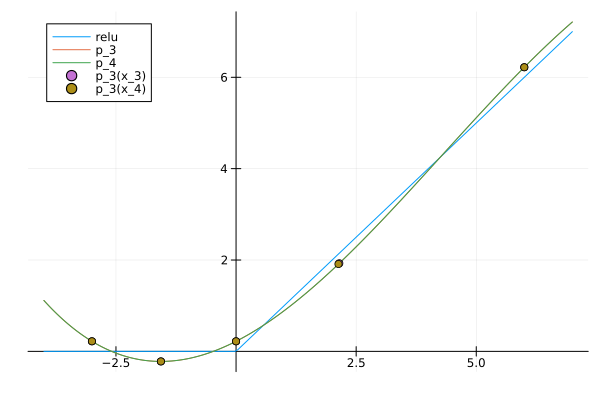

In [37]:
idx = 3
xs = range(-3 - 1, 6 + 1, 200)
plot(xs, f.(xs), label="relu", framestyle=:origin)
plot!(xs, pis[idx].(xs), label="p_$idx")
plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)")
scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)")
scatter!(xis[idx+1], pis[idx].(xis[idx+1]), label="p_$idx(x_$(idx+1))")

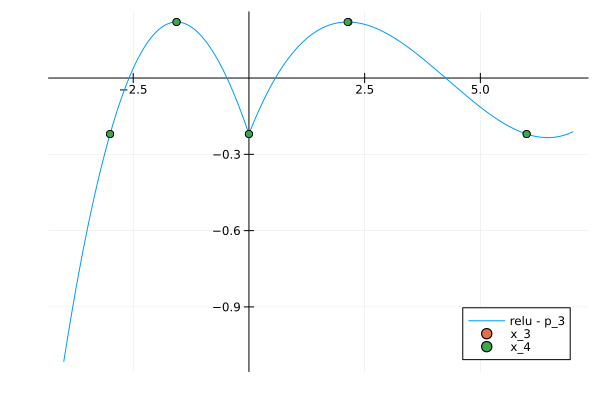

In [6]:
idx = 3

dfun = x -> f(x) - pis[idx](x)

xs = range(-3 - 1, 6 + 1, 200)
plot(xs, dfun.(xs), label="relu - p_$idx", framestyle=:origin)
scatter!(xis[idx], dfun.(xis[idx]), label="x_$idx")
scatter!(xis[idx+1], dfun.(xis[idx+1]), label="x_$(idx+1)")

## Figs for Presentation

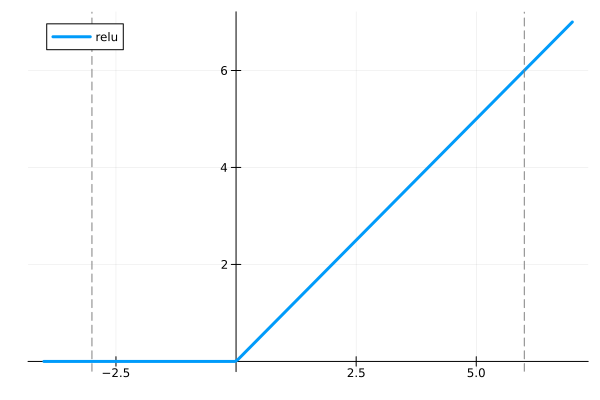

In [8]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 1, 6 + 1, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx")
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)")
#scatter!(x_err, pis[idx].(x_err), label="x_err")

#plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)")
#scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))")

In [9]:
savefig(pl, "presentation/remez/01_relu.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/01_relu.pdf"

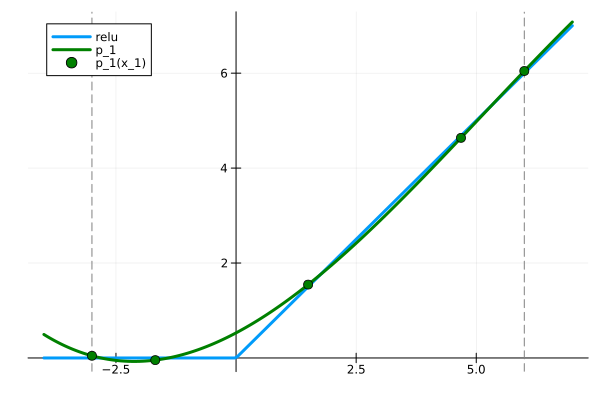

In [25]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 1, 6 + 1, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)
#scatter!(x_err, pis[idx].(x_err), label="x_err")

#plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)")
#scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))")

In [26]:
savefig(pl, "presentation/remez/02_poly1.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/02_poly1.pdf"

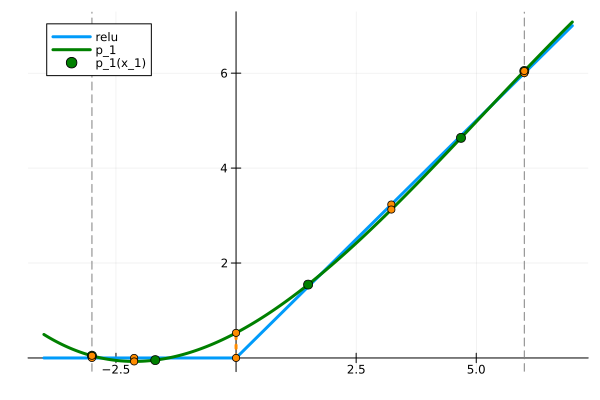

In [27]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 1, 6 + 1, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
for x_e in x_err
    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
end

current()

#plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)")
#scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))")

In [28]:
savefig(pl, "presentation/remez/03_error.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/03_error.pdf"

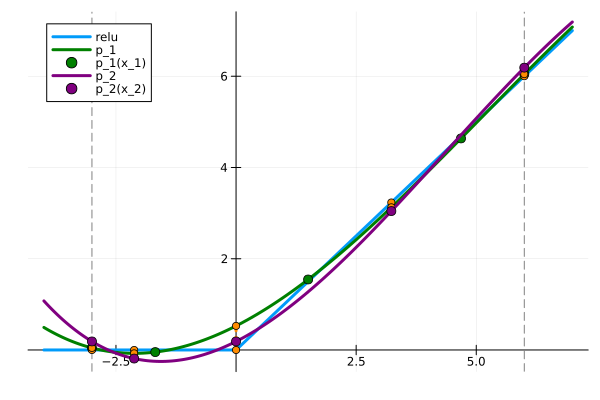

In [31]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 1, 6 + 1, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
for x_e in x_err
    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
end

plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))", color=:purple, markersize=5)

In [32]:
savefig(pl, "presentation/remez/04_fit_poly2.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/04_fit_poly2.pdf"

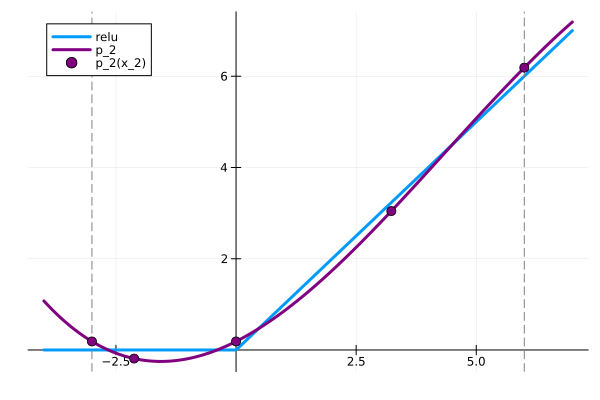

In [33]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 1, 6 + 1, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))", color=:purple, markersize=5)

In [34]:
savefig(pl, "presentation/remez/05_poly2.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/05_poly2.pdf"

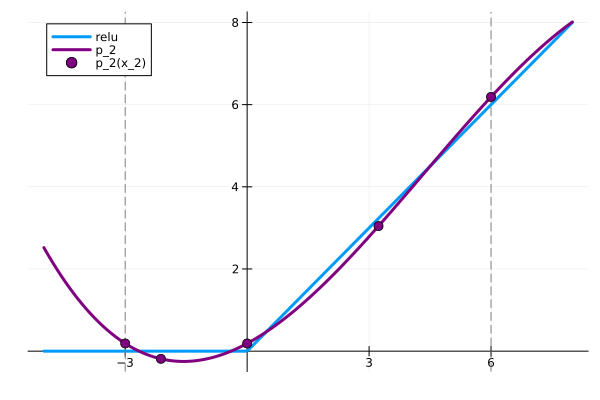

In [41]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 2, 6 + 2, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))", color=:purple, markersize=5)

In [42]:
savefig(pl, "presentation/remez/06_zoom_out1.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/06_zoom_out1.pdf"

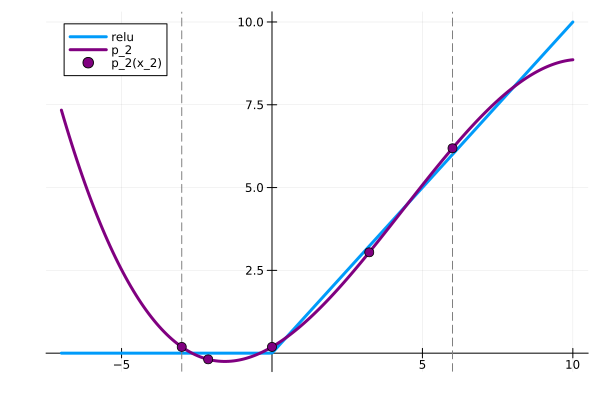

In [43]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 4, 6 + 4, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="p_$(idx+1)", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label="p_$(idx+1)(x_$(idx+1))", color=:purple, markersize=5)

In [44]:
savefig(pl, "presentation/remez/07_zoom_out2.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/07_zoom_out2.pdf"

In [56]:
cs5, ϵ = VeryDiff.approx_relu_poly(-3., 6., 5, max_iter=100)
cs10, ϵ = VeryDiff.approx_relu_poly(-3., 6., 10, max_iter=100)
cs15, ϵ = VeryDiff.approx_relu_poly(-3., 6., 15, max_iter=100)


p5 = VeryDiff.make_eval_chebyshev(cs5, -3., 6.)
p10 = VeryDiff.make_eval_chebyshev(cs10, -3., 6.)
p15 = VeryDiff.make_eval_chebyshev(cs15, -3., 6.)

#31 (generic function with 1 method)

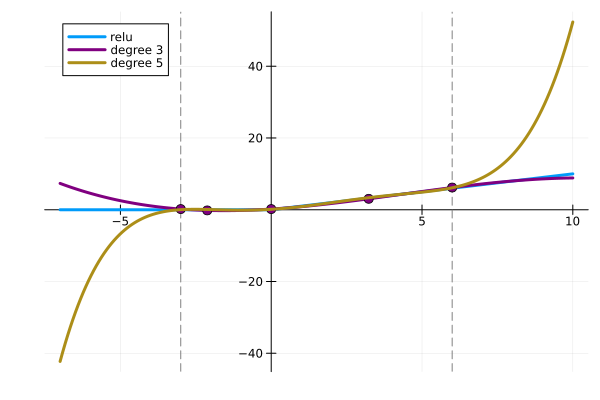

In [65]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 4, 6 + 4, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="degree 3", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label=false, color=:purple, markersize=5)

plot!(xs, p5.(xs), label="degree 5", linewidth=3)
#plot!(xs, p10.(xs), label="degree 10", color=:green, linewidth=3)
#plot!(xs, p15.(xs), label="degree 15", color=:green, linewidth=3)

In [66]:
savefig(pl, "presentation/remez/08_zoom_out_degree_5.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/08_zoom_out_degree_5.pdf"

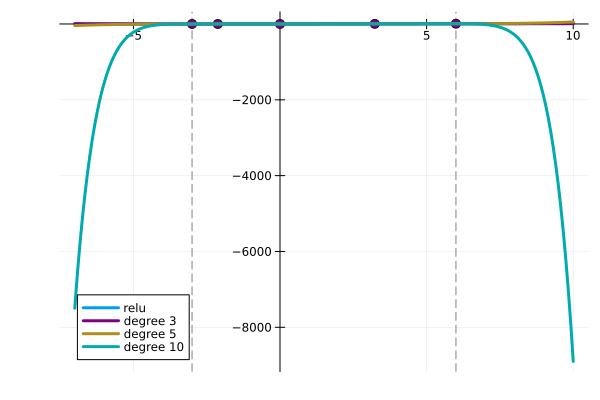

In [67]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 4, 6 + 4, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="degree 3", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label=false, color=:purple, markersize=5)

plot!(xs, p5.(xs), label="degree 5", linewidth=3)
plot!(xs, p10.(xs), label="degree 10", linewidth=3)
#plot!(xs, p15.(xs), label="degree 15", color=:green, linewidth=3)

In [68]:
savefig(pl, "presentation/remez/09_zoom_out_degree_10.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/09_zoom_out_degree_10.pdf"

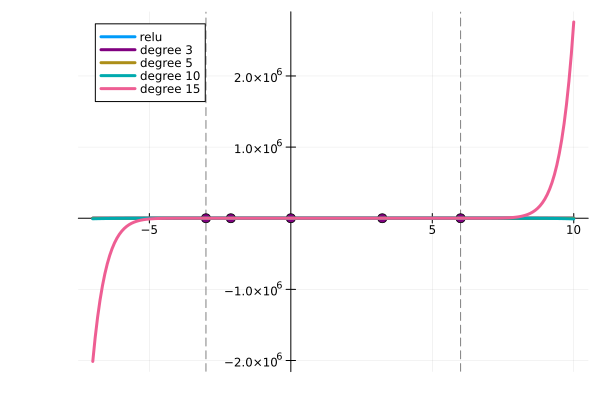

In [69]:
idx = 1

x_err, y_err = VeryDiff.relu_error_cheby(cis[idx], -3., 6.)

xs = range(-3 - 4, 6 + 4, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, linewidth=3)

vline!([-3., 6.], linestyle=:dash, color=:gray, label=false)

#plot!(xs, pis[idx].(xs), label="p_$idx", linewidth=3, color=:green)
#scatter!(xis[idx], pis[idx].(xis[idx]), label="p_$idx(x_$idx)", markersize=5, color=:green)

# Add dotted error lines
#for x_e in x_err
#    plot!([x_e, x_e], [f(x_e), pis[idx](x_e)], color=:darkorange, ls=:dot, lw=3, marker=:circle, label=false)
#end

plot!(xs, pis[idx+1].(xs), label="degree 3", color=:purple, linewidth=3)
scatter!(xis[idx+1], pis[idx+1].(xis[idx+1]), label=false, color=:purple, markersize=5)

plot!(xs, p5.(xs), label="degree 5", linewidth=3)
plot!(xs, p10.(xs), label="degree 10", linewidth=3)
plot!(xs, p15.(xs), label="degree 15", linewidth=3)

In [70]:
savefig(pl, "presentation/remez/10_zoom_out_degree_15.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/remez/10_zoom_out_degree_15.pdf"

# Linear Approximation for Polynomial

In [76]:
f = x -> max(0, x)
l = -2.
u = 2.
degree = 5

fontsize = 12

cs, ϵ = VeryDiff.approx_relu_poly(l, u, degree, verbosity=3, max_iter=100)

step, |error|,  |level|,  tol_diff, ref_diff
1     0.044658  0.044658  0.000000  4.000000
	p = [0.6220084679281463, 1.0000000000000002, 0.45534180126147955, 1.2490009027033011e-17, -0.1220084679281462, -5.551115123125783e-18]
	x_cur = [2.0, 1.7320508075688774, 1.0000000000000002, 1.2246467991473532e-16, -0.9999999999999996, -1.7320508075688774, -2.0]
Tolerance of 1.0e-10 reached (1.1047887138522962e-16)!


([0.6220084679281463, 1.0000000000000002, 0.45534180126147955, 1.2490009027033011e-17, -0.1220084679281462, -5.551115123125783e-18], 0.044658198738520616)

In [81]:
p = VeryDiff.make_eval_chebyshev(cs, l, u)

#31 (generic function with 1 method)

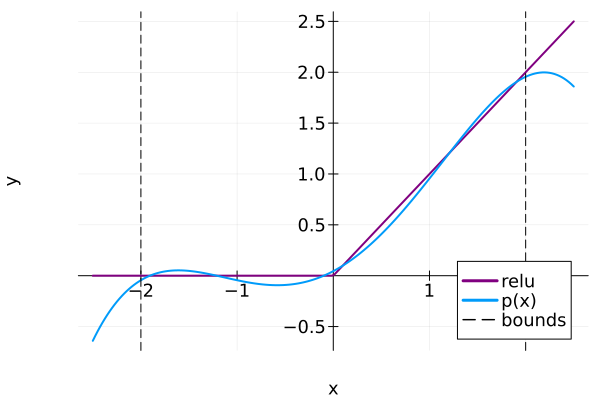

In [103]:
xs = range(l-0.5, u+0.5, 200)
pl = plot(xs, f.(xs), label="relu", framestyle=:origin, xlabel="x", ylabel="y", legendfontsize=fontsize, 
     xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, linewidth=2, color=:purple)
plot!(xs, p.(xs), label="p(x)", linewidth=2, color=1)

vline!([l, u], label="bounds", color=:black, linestyle=:dash)

In [104]:
savefig(pl, "presentation/synthesis/01_poly_fit.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/synthesis/01_poly_fit.pdf"

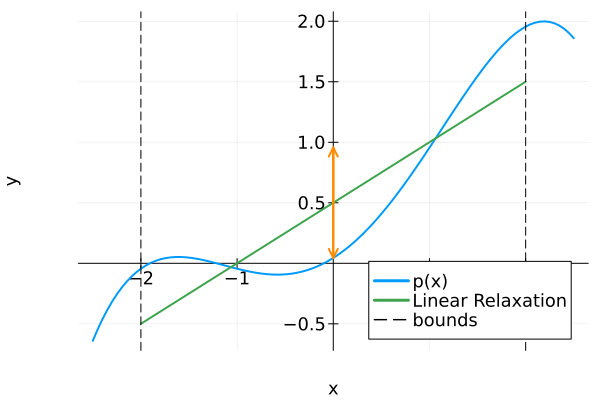

In [105]:
fontsize = 12

xs = range(l .- 0.5, u .+ 0.5, 100)
xs2 = range(l, u, 100)

a, b, ϵ = VeryDiff.get_linear_relaxation_cheby(reshape(cs, 1, :), [l], [u], [l], [u])

pl = plot(xs, p.(xs), label="p(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=2, xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, 
legendfontsize=fontsize)
plot!(xs2, a[1] * xs2 .+ b[1], label="Linear Relaxation", linewidth=2, color=3)


#plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], fillrange=a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, color=3, alpha=0.2)
#plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], label=false, linewidth=2, color=3)
#plot!(xs2, a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, linewidth=2, color=3)

y =  a[1] * 0 .+ b[1]
# Draw a vertical line between f(x) and f(x) + eps(x)
plot!([0, 0], [y, y + ϵ[1]], color=:darkorange, label=false, lw=2)
plot!([0, 0], [y, y - ϵ[1]], color=:darkorange, label=false, l2=2)
# Add arrows on both ends
quiver!([0, 0], [y, y], quiver=([0, 0], [ϵ[1], -ϵ[1]]),
        color=:darkorange, label="error", arrow=true, lw=2)

vline!([l, u], label="bounds", linestyle=:dash, color=:black)

In [106]:
savefig(pl, "presentation/synthesis/02_linear_err.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/synthesis/02_linear_err.pdf"

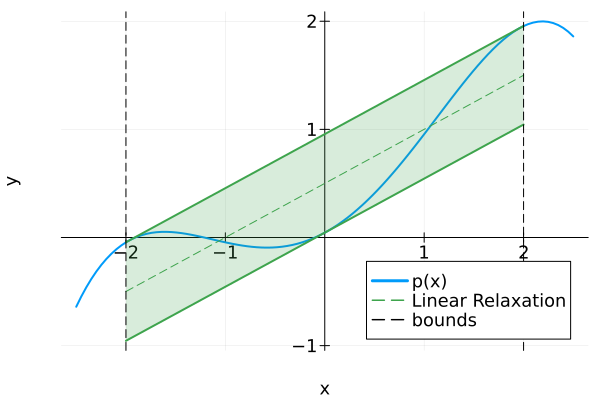

In [107]:
fontsize = 12

xs = range(l .- 0.5, u .+ 0.5, 100)
xs2 = range(l, u, 100)

a, b, ϵ = VeryDiff.get_linear_relaxation_cheby(reshape(cs, 1, :), [l], [u], [l], [u])

pl = plot(xs, p.(xs), label="p(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=2, xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, 
legendfontsize=fontsize)
plot!(xs2, a[1] * xs2 .+ b[1], label="Linear Relaxation", linewidth=1, color=3, linestyle=:dash)


plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], fillrange=a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, color=3, alpha=0.2)
plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], label=false, linewidth=2, color=3)
plot!(xs2, a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, linewidth=2, color=3)

y =  a[1] * 0 .+ b[1]
# Draw a vertical line between f(x) and f(x) + eps(x)
#plot!([0, 0], [y, y + ϵ[1]], color=:darkorange, label=false, lw=2)
#plot!([0, 0], [y, y - ϵ[1]], color=:darkorange, label=false, l2=2)
# Add arrows on both ends
#quiver!([0, 0], [y, y], quiver=([0, 0], [ϵ[1], -ϵ[1]]),
#        color=:darkorange, label="error", arrow=true, lw=2)

vline!([l, u], label="bounds", linestyle=:dash, color=:black)

In [108]:
savefig(pl, "presentation/synthesis/03_linear_relaxation.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/synthesis/03_linear_relaxation.pdf"

step, |error|,  |level|,  tol_diff, ref_diff
1     0.153572  0.000982  0.070642  3.820000
	p = [0.8856847535380464, 1.2660042339640731, 0.3515180868713797, -0.08333333333333337, -0.03318475353804647, 0.022329099369260128]
	x_cur = [2.41, 2.1541085212282782, 1.4550000000000005, 0.5000000000000002, -0.4549999999999995, -1.1541085212282778, -1.4100000000000001]
2     0.074789  0.030765  0.020381  0.401049
	p = [0.8692068493656185, 1.2672436498902735, 0.37582311016754527, -0.12277755937314859, -0.06782092652716568, 0.0635083900793465]
	x_cur = [-1.4100000000000001, -1.2822649215567576, -0.7308306571741315, 0.0, 0.870239343764968, 1.8027497567298965, 2.3368210410924033]
3     0.053948  0.052522  0.000660  0.073779
	p = [0.8711375513809371, 1.258154119256253, 0.35430158554438146, -0.11731057459832844, -0.06904047464448808, 0.06807668621294914]
	x_cur = [-1.41, -1.1492120868985531, -0.4182634089192011, 0.0, 0.4691905452952685, 1.5212822573738651, 2.3093328534770388]
4     0.052700  0.052699  

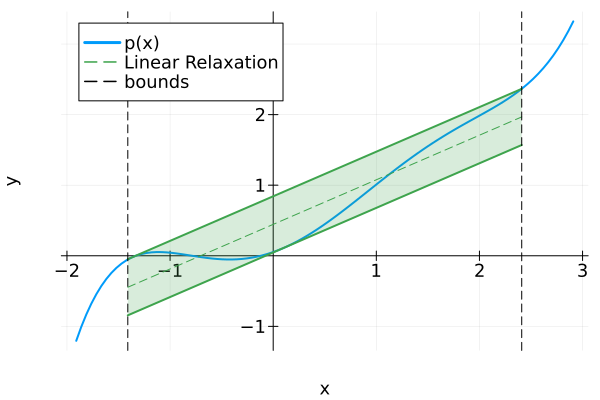

In [110]:
fontsize = 12

l = -1.41
u = 2.41

xs = range(l .- 0.5, u .+ 0.5, 100)
xs2 = range(l, u, 100)


cs, ϵ = VeryDiff.approx_relu_poly(l, u, degree, verbosity=3, max_iter=100)
p = VeryDiff.make_eval_chebyshev(cs, l, u)

a, b, ϵ = VeryDiff.get_linear_relaxation_cheby(reshape(cs, 1, :), [l], [u], [l], [u])

pl = plot(xs, p.(xs), label="p(x)", xlabel="x", ylabel="y", framestyle=:origin, linewidth=2, xguidefontsize=fontsize, yguidefontsize=fontsize, xtickfontsize=fontsize, ytickfontsize=fontsize, 
legendfontsize=fontsize)
plot!(xs2, a[1] * xs2 .+ b[1], label="Linear Relaxation", linewidth=1, color=3, linestyle=:dash)


plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], fillrange=a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, color=3, alpha=0.2)
plot!(xs2, a[1] * xs2 .+ b[1] .- ϵ[1], label=false, linewidth=2, color=3)
plot!(xs2, a[1] * xs2 .+ b[1] .+ ϵ[1], label=false, linewidth=2, color=3)

vline!([l, u], label="bounds", linestyle=:dash, color=:black)

In [111]:
savefig(pl, "presentation/synthesis/04_linear_relaxation2.pdf")

"/home/philipp/VerifyNN/VeryDiffPolyExperiments/running_example/presentation/synthesis/04_linear_relaxation2.pdf"